<a href="https://colab.research.google.com/github/aabyyaann/UAS-ML/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow optuna mlflow lime

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import optuna

import mlflow
import mlflow.tensorflow

from lime.lime_tabular import LimeTabularExplainer

In [3]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available: 0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DATA_PATH = "/content/drive/MyDrive/Midterm ML/midterm-regresi-dataset.csv"

df = pd.read_csv(
    DATA_PATH,
    header=None
)

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (515345, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [6]:
target_col = "Year"

feature_names = [f"feature_{i}" for i in range(1, df.shape[1])]
df.columns = [target_col] + feature_names

print("Jumlah kolom:", len(df.columns))
df.head()

Jumlah kolom: 91


,Year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [7]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# target juga kita jadikan float32
df = df.astype(np.float32)

print(df.dtypes.head())
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Year         float32
feature_1    float32
feature_2    float32
feature_3    float32
feature_4    float32
dtype: object
Memory usage (MB): 178.9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Year        515345 non-null  float32
 1   feature_1   515345 non-null  float32
 2   feature_2   515345 non-null  float32
 3   feature_3   515345 non-null  float32
 4   feature_4   515345 non-null  float32
 5   feature_5   515345 non-null  float32
 6   feature_6   515345 non-null  float32
 7   feature_7   515345 non-null  float32
 8   feature_8   515345 non-null  float32
 9   feature_9   515345 non-null  float32
 10  feature_10  515345 non-null  float32
 11  feature_11  515345 non-null  float32
 12  feature_12  515345 non-null  float32
 13  feature_13  515345 non-null  float32
 14  feature_14  515345 non-null  float32
 15  feature_15  515345 non-null  float32
 16  feature_16  515345 non-null  float32
 17  feature_17  515345 non-null  float32
 18  feature_18  515345 non-null  float32
 19  fe

In [9]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplicate rows:", duplicate_count)

Jumlah duplicate rows: 214


In [10]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary.head(20)

,0
Year,0
feature_1,0
feature_2,0
feature_3,0
feature_4,0
feature_5,0
feature_6,0
feature_7,0
feature_8,0
feature_9,0


In [11]:
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values setelah imputasi:", df.isnull().sum().sum())
else:
    print("Tidak ada missing values.")

Tidak ada missing values.


In [12]:
df["Year"].describe()

,Year
count,515345.000000
mean,1998.396851
std,12.595524
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000


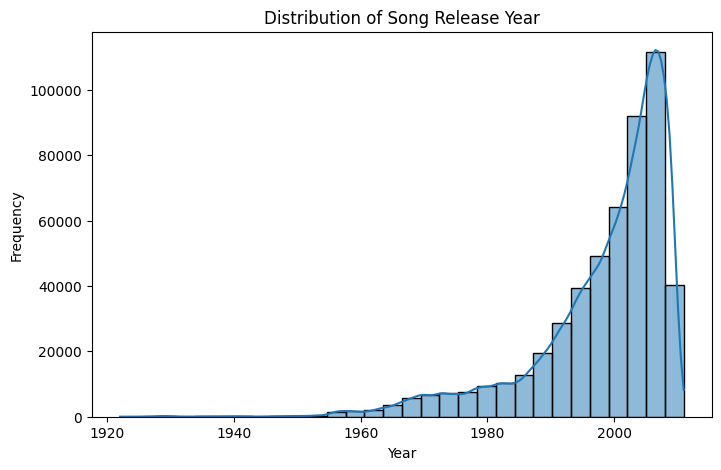

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Year"], bins=30, kde=True)
plt.title("Distribution of Song Release Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

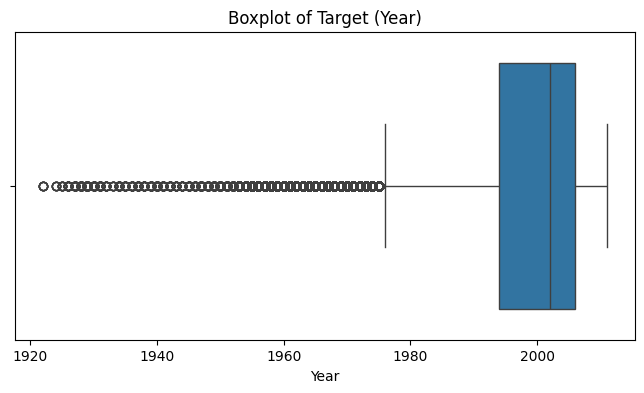

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Year"])
plt.title("Boxplot of Target (Year)")
plt.show()

In [15]:
X = df.drop(columns=["Year"])
y = df["Year"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (515345, 90)
y shape: (515345,)


In [16]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print("Train shape:", X_train_df.shape, y_train.shape)
print("Test shape :", X_test_df.shape, y_test.shape)

Train shape: (412276, 90) (412276,)
Test shape : (103069, 90) (103069,)


In [17]:
X_train_df = X_train_df.copy()
X_test_df = X_test_df.copy()

lower_q = X_train_df.quantile(0.01)
upper_q = X_train_df.quantile(0.99)

X_train_df = X_train_df.clip(lower=lower_q, upper=upper_q, axis=1)
X_test_df = X_test_df.clip(lower=lower_q, upper=upper_q, axis=1)

print("Outlier capping selesai.")

Outlier capping selesai.


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_df).astype(np.float32)
X_test_scaled = scaler.transform(X_test_df).astype(np.float32)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (412276, 90)
X_test_scaled : (103069, 90)


In [19]:
X_train_base = X_train_scaled
X_test_base = X_test_scaled

print("Baseline feature shape:", X_train_base.shape)

Baseline feature shape: (412276, 90)


In [20]:
k_best = min(60, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_regression, k=k_best)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print("Jumlah fitur setelah SelectKBest:", X_train_kbest.shape[1])
print("Contoh fitur terpilih:", selected_features[:10])

Jumlah fitur setelah SelectKBest: 60
Contoh fitur terpilih: ['feature_1', 'feature_3', 'feature_6', 'feature_7', 'feature_8', 'feature_10', 'feature_11', 'feature_12', 'feature_14', 'feature_16']


In [21]:
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train_kbest).astype(np.float32)
X_test_pca = pca.transform(X_test_kbest).astype(np.float32)

print("Shape setelah PCA (train):", X_train_pca.shape)
print("Shape setelah PCA (test) :", X_test_pca.shape)
print("Explained variance ratio total:", pca.explained_variance_ratio_.sum())

Shape setelah PCA (train): (412276, 47)
Shape setelah PCA (test) : (103069, 47)
Explained variance ratio total: 0.95491284


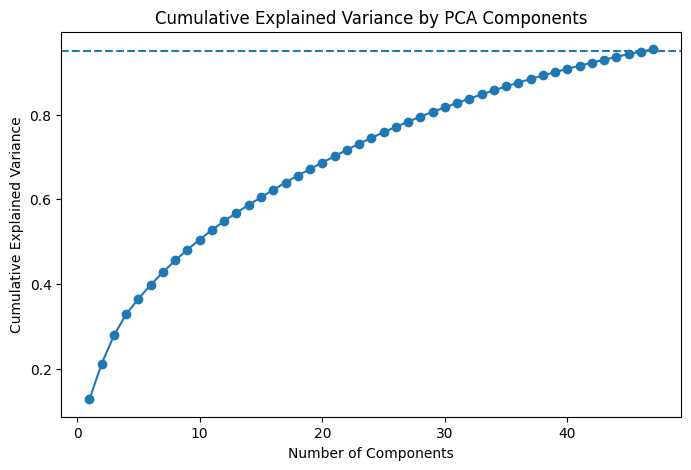

In [22]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, linestyle='--')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [23]:
def build_regression_model(
    input_dim,
    units1=128,
    units2=64,
    dropout1=0.3,
    dropout2=0.2,
    learning_rate=1e-3
):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(units1, activation="relu"),
        BatchNormalization(),
        Dropout(dropout1),

        Dense(units2, activation="relu"),
        BatchNormalization(),
        Dropout(dropout2),

        Dense(1, activation="linear")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

In [24]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [25]:
baseline_model = build_regression_model(
    input_dim=X_train_pca.shape[1],
    units1=128,
    units2=64,
    dropout1=0.3,
    dropout2=0.2,
    learning_rate=1e-3
)

history_baseline = baseline_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 3660159.2500 - mae: 1911.5790 - val_loss: 3044341.5000 - val_mae: 1744.7620 - learning_rate: 0.0010
Epoch 2/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 2203681.0000 - mae: 1474.5193 - val_loss: 1368135.3750 - val_mae: 1169.6023 - learning_rate: 0.0010
Epoch 3/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 758438.1875 - mae: 847.6507 - val_loss: 285495.5000 - val_mae: 534.1577 - learning_rate: 0.0010
Epoch 4/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 114432.8516 - mae: 298.5463 - val_loss: 12628.2852 - val_mae: 111.7094 - learning_rate: 0.0010
Epoch 5/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 17951.7324 - mae: 106.2084 - val_loss: 239.7299 - val_mae: 13.1298 - learning_rate: 0.0010
Epoch 6/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 15818.0479 - mae: 100.3184 - val_loss: 156.9674 - val_mae: 10.4215 - learning_rate: 0.0010
Epoch 7/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step 

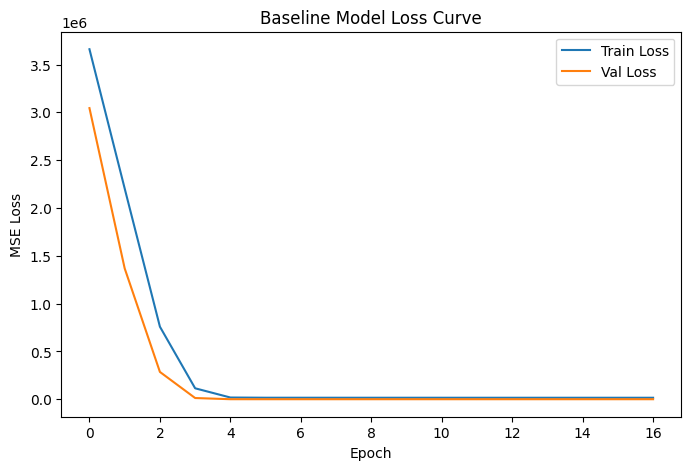

In [26]:
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [27]:
y_pred_baseline = baseline_model.predict(X_test_pca).flatten()

3221/3221 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [28]:
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("=== BASELINE MODEL ===")
print("MSE  :", baseline_mse)
print("RMSE :", baseline_rmse)
print("MAE  :", baseline_mae)
print("R2   :", baseline_r2)

=== BASELINE MODEL ===
MSE  : 125.96292114257812
RMSE : 11.223320415214836
MAE  : 9.363946914672852
R2   : -0.05837845802307129


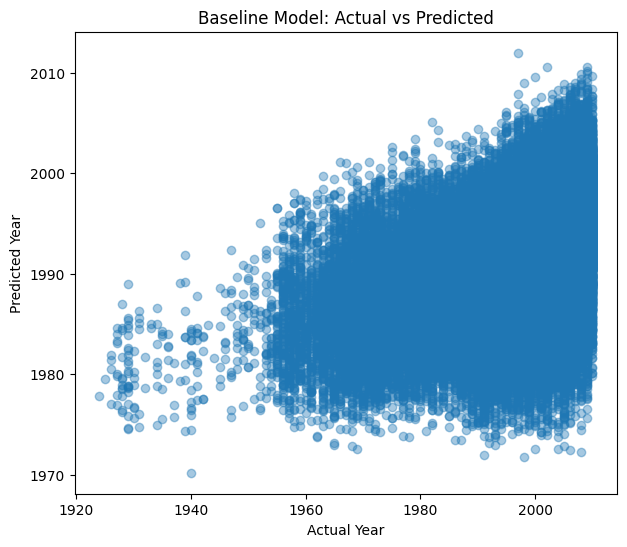

In [29]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_baseline, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Baseline Model: Actual vs Predicted")
plt.show()

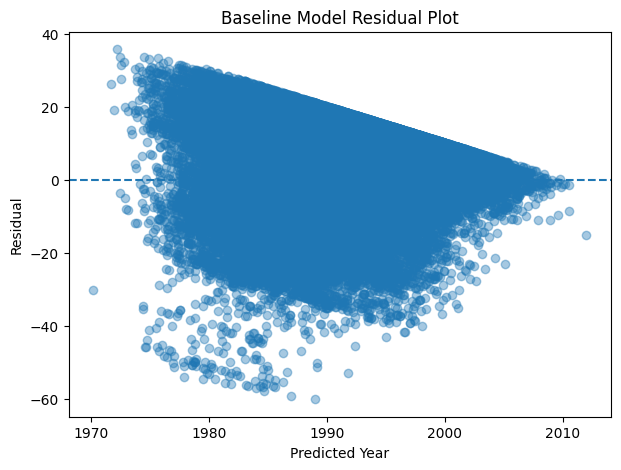

In [30]:
baseline_residuals = y_test - y_pred_baseline

plt.figure(figsize=(7,5))
plt.scatter(y_pred_baseline, baseline_residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Baseline Model Residual Plot")
plt.show()

In [31]:
X_tune, _, y_tune, _ = train_test_split(
    X_train_pca,
    y_train,
    train_size=0.4,
    random_state=SEED
)

print("Shape untuk Optuna:", X_tune.shape, y_tune.shape)

Shape untuk Optuna: (164910, 47) (164910,)


In [32]:
def objective(trial):
    units1 = trial.suggest_categorical("units1", [64, 128, 256])
    units2 = trial.suggest_categorical("units2", [32, 64, 128])
    dropout1 = trial.suggest_float("dropout1", 0.1, 0.5)
    dropout2 = trial.suggest_float("dropout2", 0.1, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    model = build_regression_model(
        input_dim=X_tune.shape[1],
        units1=units1,
        units2=units2,
        dropout1=dropout1,
        dropout2=dropout2,
        learning_rate=lr
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_tune,
        y_tune,
        validation_split=0.2,
        epochs=15,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])

    tf.keras.backend.clear_session()
    gc.collect()

    return best_val_loss

In [33]:
study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=12,
    show_progress_bar=True
)

print("Best trial:")
print(study.best_trial.value)
print("Best params:")
print(study.best_params)

[I 2026-06-21 19:43:49,328] A new study created in memory with name: no-name-370a687e-bb9f-4c36-8553-5512fd7cf5b3


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2026-06-21 19:44:36,787] Trial 0 finished with value: 1233968.0 and parameters: {'units1': 128, 'units2': 32, 'dropout1': 0.2243857300512281, 'dropout2': 0.4270351060330069, 'learning_rate': 0.0005518035773663788, 'batch_size': 256}. Best is trial 0 with value: 1233968.0.
[I 2026-06-21 19:45:17,644] Trial 1 finished with value: 603955.0 and parameters: {'units1': 128, 'units2': 64, 'dropout1': 0.42247878531023786, 'dropout2': 0.32793033476235134, 'learning_rate': 0.0008792105466634325, 'batch_size': 512}. Best is trial 1 with value: 603955.0.
[I 2026-06-21 19:45:52,071] Trial 2 finished with value: 126.88847351074219 and parameters: {'units1': 128, 'units2': 64, 'dropout1': 0.48196006833822636, 'dropout2': 0.14377634239887557, 'learning_rate': 0.003986896423750202, 'batch_size': 512}. Best is trial 2 with value: 126.88847351074219.
[I 2026-06-21 19:46:19,351] Trial 3 finished with value: 608.30615234375 and parameters: {'units1': 128, 'units2': 64, 'dropout1': 0.16419648150323096, '

In [34]:
best_params = study.best_params

best_model = build_regression_model(
    input_dim=X_train_pca.shape[1],
    units1=best_params["units1"],
    units2=best_params["units2"],
    dropout1=best_params["dropout1"],
    dropout2=best_params["dropout2"],
    learning_rate=best_params["learning_rate"]
)

early_stop_best = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_best = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

history_best = best_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop_best, reduce_lr_best],
    verbose=1
)

Epoch 1/40
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 254655.3750 - mae: 214.0724 - val_loss: 124.5914 - val_mae: 8.9073 - learning_rate: 0.0095
Epoch 2/40
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 5500.8389 - mae: 59.1173 - val_loss: 123.2904 - val_mae: 8.8827 - learning_rate: 0.0095
Epoch 3/40
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 5498.1074 - mae: 59.1097 - val_loss: 136.6223 - val_mae: 9.8390 - learning_rate: 0.0095
Epoch 4/40
2572/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5505.8448 - mae: 59.1528
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004756464157253504.
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 5500.0933 - mae: 59.1048 - val_loss: 127.2462 - val_mae: 9.3170 - learning_rate: 0.0095
Epoch 5/40
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 5433.3008 - mae: 58.7849 - val_loss: 163.3271 - val_mae: 11.2821 - learning_rate: 0.0048
Epoch 6/40
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 5438.7134 - mae: 58.8594 - 

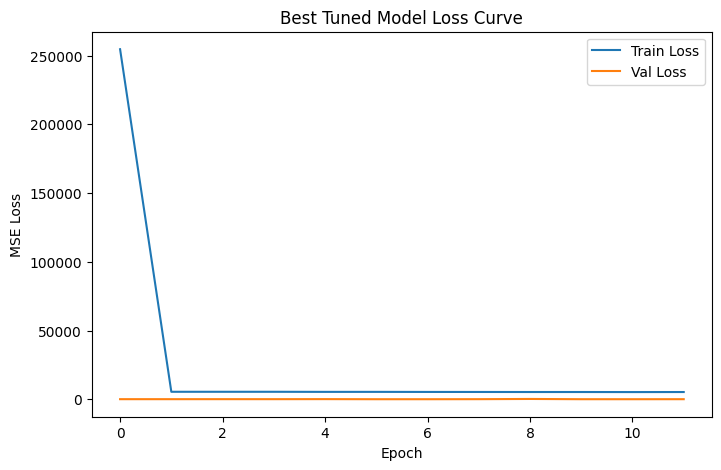

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history_best.history["loss"], label="Train Loss")
plt.plot(history_best.history["val_loss"], label="Val Loss")
plt.title("Best Tuned Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [36]:
y_pred_best = best_model.predict(X_test_pca).flatten()

3221/3221 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [37]:
best_mse = mean_squared_error(y_test, y_pred_best)
best_rmse = np.sqrt(best_mse)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print("=== TUNED MODEL ===")
print("MSE  :", best_mse)
print("RMSE :", best_rmse)
print("MAE  :", best_mae)
print("R2   :", best_r2)

=== TUNED MODEL ===
MSE  : 94.0917739868164
RMSE : 9.700091442188388
MAE  : 7.239488124847412
R2   : 0.20941251516342163


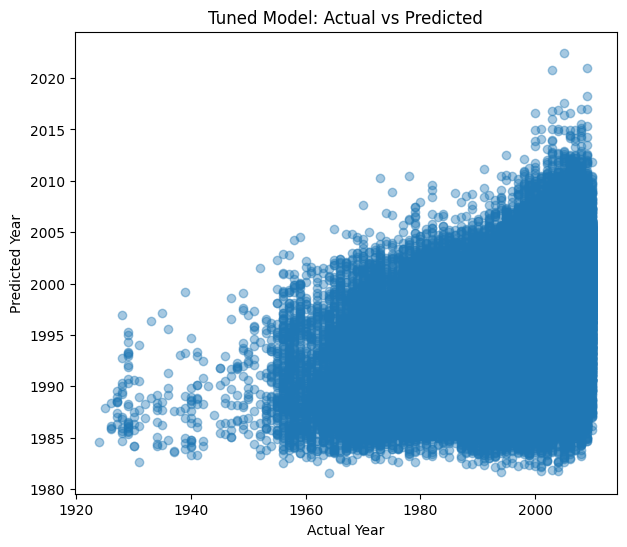

In [38]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Tuned Model: Actual vs Predicted")
plt.show()

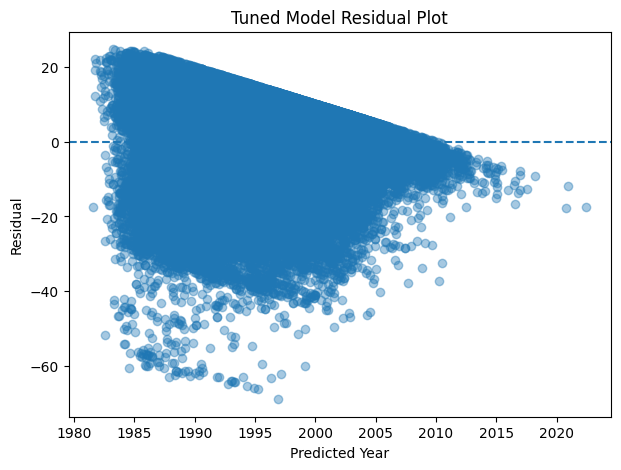

In [39]:
best_residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))
plt.scatter(y_pred_best, best_residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Tuned Model Residual Plot")
plt.show()

In [40]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "MSE": [baseline_mse, best_mse],
    "RMSE": [baseline_rmse, best_rmse],
    "MAE": [baseline_mae, best_mae],
    "R2": [baseline_r2, best_r2]
})

comparison_df

,Model,MSE,RMSE,MAE,R2
0,Baseline,125.962921,11.223320,9.363947,-0.058378
1,Tuned,94.091774,9.700091,7.239488,0.209413


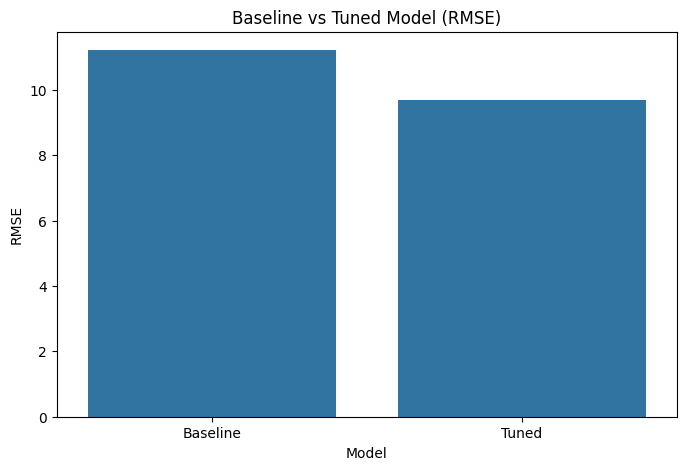

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x="Model", y="RMSE")
plt.title("Baseline vs Tuned Model (RMSE)")
plt.show()

In [42]:
mlflow.set_experiment("Song Year Prediction - Deep Learning Regression")

with mlflow.start_run(run_name="tuned_regression_model"):
    mlflow.log_param("pipeline", "StandardScaler + SelectKBest + PCA + DeepLearning")

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric("baseline_mse", baseline_mse)
    mlflow.log_metric("baseline_rmse", baseline_rmse)
    mlflow.log_metric("baseline_mae", baseline_mae)
    mlflow.log_metric("baseline_r2", baseline_r2)

    mlflow.log_metric("best_mse", best_mse)
    mlflow.log_metric("best_rmse", best_rmse)
    mlflow.log_metric("best_mae", best_mae)
    mlflow.log_metric("best_r2", best_r2)

    mlflow.tensorflow.log_model(best_model, "song_year_regression_model")

2026/06/21 19:55:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 19:55:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [43]:
lime_train_size = min(2000, X_train_pca.shape[0])

lime_indices = np.random.choice(
    X_train_pca.shape[0],
    size=lime_train_size,
    replace=False
)

X_train_lime = X_train_pca[lime_indices]

In [44]:
pca_feature_names = [f"PC_{i+1}" for i in range(X_train_pca.shape[1])]

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=pca_feature_names,
    mode="regression"
)

In [45]:
exp = explainer.explain_instance(
    data_row=X_test_pca[0],
    predict_fn=lambda x: best_model.predict(x, verbose=0).flatten(),
    num_features=min(10, X_test_pca.shape[1])
)

exp.show_in_notebook()

In [46]:
best_model.save("song_year_regression_best_model.keras")
print("Model saved successfully.")

Model saved successfully.


In [47]:
final_result = pd.DataFrame({
    "Metric": ["Baseline_MSE", "Baseline_RMSE", "Baseline_MAE", "Baseline_R2",
               "Best_MSE", "Best_RMSE", "Best_MAE", "Best_R2"],
    "Value": [baseline_mse, baseline_rmse, baseline_mae, baseline_r2,
              best_mse, best_rmse, best_mae, best_r2]
})

final_result.to_csv("regression_metrics_comparison.csv", index=False)
final_result

,Metric,Value
0,Baseline_MSE,125.962921
1,Baseline_RMSE,11.223320
2,Baseline_MAE,9.363947
3,Baseline_R2,-0.058378
4,Best_MSE,94.091774
5,Best_RMSE,9.700091
6,Best_MAE,7.239488
7,Best_R2,0.209413


In [48]:
prediction_df = pd.DataFrame({
    "Actual_Year": y_test.values,
    "Predicted_Year": y_pred_best
})

prediction_df.to_csv("song_year_predictions.csv", index=False)
prediction_df.head()

,Actual_Year,Predicted_Year
0,2008.0,1997.058105
1,2001.0,1985.045044
2,2006.0,1993.964355
3,2008.0,1989.659058
4,1998.0,1987.998169


In [49]:
print("KESIMPULAN SINGKAT")
print("- Model regresi deep learning berhasil dibangun untuk memprediksi tahun rilis lagu.")
print("- Pipeline meliputi preprocessing, handling missing values, scaling, feature selection, PCA, baseline model, Optuna tuning, evaluasi, MLflow, dan LIME.")
print("- Performa akhir dapat dibandingkan antara baseline dan tuned model menggunakan MSE, RMSE, MAE, dan R2.")

KESIMPULAN SINGKAT
- Model regresi deep learning berhasil dibangun untuk memprediksi tahun rilis lagu.
- Pipeline meliputi preprocessing, handling missing values, scaling, feature selection, PCA, baseline model, Optuna tuning, evaluasi, MLflow, dan LIME.
- Performa akhir dapat dibandingkan antara baseline dan tuned model menggunakan MSE, RMSE, MAE, dan R2.
